In [60]:
from rdkit.Chem import AllChem as Chem

import pandas as pd

from chembl_structure_pipeline import standardizer

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors

import seaborn as sns
import numpy as np

from rdkit.Chem import MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw

from rdkit import DataStructs

from sklearn import metrics
import numpy

from sklearn.manifold import TSNE
from umap import UMAP
from rdkit.SimDivFilters import rdSimDivPickers

from rdkit.Chem import ChemicalFeatures
from rdkit.Chem.Pharm2D import Gobbi_Pharm2D, Generate, SigFactory

from rdkit.Chem.Scaffolds import MurckoScaffold

import matplotlib.pyplot as plt

In [44]:
fdefName = 'BaseFeatures.fdef' # Standard RDKit feature definitions
featFactory = ChemicalFeatures.BuildFeatureFactory(fdefName)

# 2. Setup the Signature Factory (defines distance bins and bit counts)
sigFactory = SigFactory(featFactory, minPointCount=2, maxPointCount=3)
sigFactory.SetBins([(0, 2), (2, 5), (5, 8)])
sigFactory.Init()

# 3. Generate the Fingerprint (returns an ExplicitBitVect)

fp = Generate.Gen2DFingerprint(mol, sigFactory)

OSError: File: BaseFeatures.fdef could not be opened.

In [43]:
mol = Chem.MolFromSmiles("O=C(C)Oc1ccccc1C(=O)O")
ph_fp = Generate.Gen2DFingerprint(mol, Gobbi_Pharm2D.factory)

In [2]:
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank_df = pd.DataFrame({"source": "drugbank", "mol": mol, "id": mol.GetProp("DATABASE_ID")} for mol in suppl if mol)
drugbank_df.set_index("id", inplace=True)

zinc_df = pd.read_csv("../data/zinc_random_structures.txt", delimiter=" ")
zinc_df.rename(columns={"zincid": "id"}, inplace=True)
zinc_df.set_index("id", inplace=True)
zinc_df['source'] = 'zinc'
zinc_df['mol'] = zinc_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
zinc_df.drop(columns=['tranche', 'SMILES'], inplace=True)

mtor_df = pd.read_csv("../data/chembl_mtor_ic50.csv", delimiter=";", usecols=["Molecule ChEMBL ID", "Smiles"])
mtor_df.rename(columns={"Molecule ChEMBL ID": "id"}, inplace=True)
mtor_df.set_index("id", inplace=True)
mtor_df['source'] = 'chembl'
mtor_df['mol'] = mtor_df['Smiles'].apply(lambda x: Chem.MolFromSmiles(x))
mtor_df.drop(columns=['Smiles'], inplace=True)

structures = pd.concat([drugbank_df, zinc_df, mtor_df])

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=1024)
structures["ECFP6"] = structures["mol"].apply(morgan_gen.GetFingerprint)
structures["explicit_bits"] = structures["mol"].apply(morgan_gen.GetFingerprintAsNumPy)

tsne_diverse = pd.read_csv(filepath_or_buffer="../data/structures_tsne.csv", index_col="id")
structures = structures.join(tsne_diverse[["picked","tsne1","tsne2"]])

In [3]:
structures

,source,mol,ECFP6,explicit_bits,picked,tsne1,tsne2
id,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,11.845649,-62.292377
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",False,13.480247,-63.899030
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",False,13.248928,-60.559788
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",False,11.222519,-64.070340
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,32.557755,-3.473266
...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",False,5.847549,93.525110
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,5.822616,94.154260
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,-35.711166,-4.213742


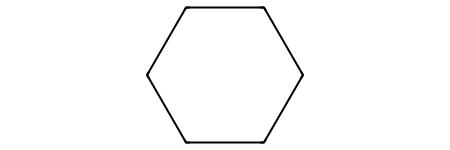

In [7]:
mol = Chem.MolFromSmiles("O=C(C)Oc1ccccc1C(=O)O")

def scaffold(mol):
    Chem.rdmolops.RemoveStereochemistry(mol) # get rid of stereo, doesn't matter much in scaffolds
    try:
        scaff = MurckoScaffold.MakeScaffoldGeneric(mol) # all atoms->C all bonds-> single
    except ValueError: # if the structure can't be represented by C atoms, just return no scaffold.
        # if such functionality is really desired, then generic graphs can be used instead of C
        return None
    scaff = MurckoScaffold.GetScaffoldForMol(scaff) # remove all sidechains
    return scaff
scaffold(mol)

In [11]:
structures["scaffold"] = structures["mol"].apply(scaffold)

In [18]:
def scaffold_to_smiles(mol):
    if mol:
        return Chem.MolToSmiles(mol)
    else:
        return ""

In [19]:
structures["scaffold_smiles"] = structures["scaffold"].apply(scaffold_to_smiles)

In [20]:
structures

,source,mol,ECFP6,explicit_bits,picked,tsne1,tsne2,scaffold,scaffold_smiles
id,,,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,11.845649,-62.292377,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCCCCCCCC(CCCCCCCCCCC1CCCC1CCCCCCCCCCC1CC...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",False,13.480247,-63.899030,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCC(CCCCCC(CCC(CCC1CCCC1)CC1CCCC1)CC1CCC2...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",False,13.248928,-60.559788,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C1CCCCC(CC2CCCCC2)CCC(CC2CCCCC2)CCCCCCCC(CC2CC...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",False,11.222519,-64.070340,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCC(CCCCCC(CCC(CCCCC1CCC2CCCCC2C1)CC1CCCC...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,32.557755,-3.473266,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C1CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC1
...,...,...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",False,5.847549,93.525110,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(CCC2CCCC(C3CCC4CCCCC4C3)C2)CC1
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,5.822616,94.154260,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(CCC2CCCC(C3CCC4CCCCC4C3)C2)CC1
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,-35.711166,-4.213742,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(C2CCC3CC4CCCC(C5CCCCC5)C4C3C2)CC1


In [33]:
structures.groupby(["source", "scaffold_smiles"]).size()

source  scaffold_smiles                                                    
chembl  C(CC1CC1)CC1CCC(C2CC(C3CC4CCC(C4)C3)C3CCC(C4CCC5(CCCC5)CC4)C3C2)CC1      1
        C(CC1CC1)CC1CCC(C2CC3CCCC3C(C3CC4CCC(C4)C3)C2)CC1                        1
        C(CC1CC1)CC1CCC(C2CC3CCCC3C(C3CC4CCC3C4)C2)CC1                           2
        C(CC1CCC(C2CCCC2)CC1)CC1CCC(C2CC3CCCC3C(C3CC4CCC(C4)C3)C2)CC1            1
        C(CCC1CCC(C2CCC3CCC4CCC(C5CCC5)C4C3C2)CC1)CC1CCC1                        2
                                                                              ... 
zinc    C1CCCC2(CC1)CC2CCC1CC(CC2CCCC2)C1                                        1
        C1CCCC2C(CC1)C2CCC12CCCC(CCC3CCC3)C1CCC2                                 1
        C1CCCCC1                                                               221
        C1CCCCCC1                                                               14
        C1CCCCCCCCC1                                                             1
Length: 579

In [35]:
scaffolds = structures.groupby('source')['scaffold_smiles'].value_counts()
scaffolds = scaffolds.to_frame().reset_index()
scaffolds['prob'] = scaffolds.groupby('source')['count'].transform(lambda x: x / x.sum())
scaffolds = scaffolds.sort_values(['prob'], ascending=[False])

In [40]:
scaffolds[:20]

,source,scaffold_smiles,count,prob
647,drugbank,C1CCCCC1,1039,0.145927
648,drugbank,,997,0.140028
0,chembl,C1CCC(C2CCC3C(C2)CC(C2CCCCC2)CC3C2CCCCC2)CC1,331,0.054947
1,chembl,C1CCC(CCC2CCCCC2C2CCC(CC3CCCCC3)CC2)CC1,277,0.045983
2,chembl,C1CCC(CC2CC3CCCCC3C2C2CCCCC2)CC1,209,0.034695
3,chembl,C1CCC(C2CC3CCCC3C(C3CCCCC3)C2)CC1,205,0.034031
4,chembl,C1CCC(CCC2CCCCC2C2CCCCC2)CC1,194,0.032205
5,chembl,C1CCC(CC2CCCCC2C2CCCCC2)CC1,193,0.032039
2194,zinc,C1CCCCC1,221,0.030780
6,chembl,C1CCC(CC2CCC(CC3CCCCC3)C(C3CCCCC3)C2)CC1,185,0.030710


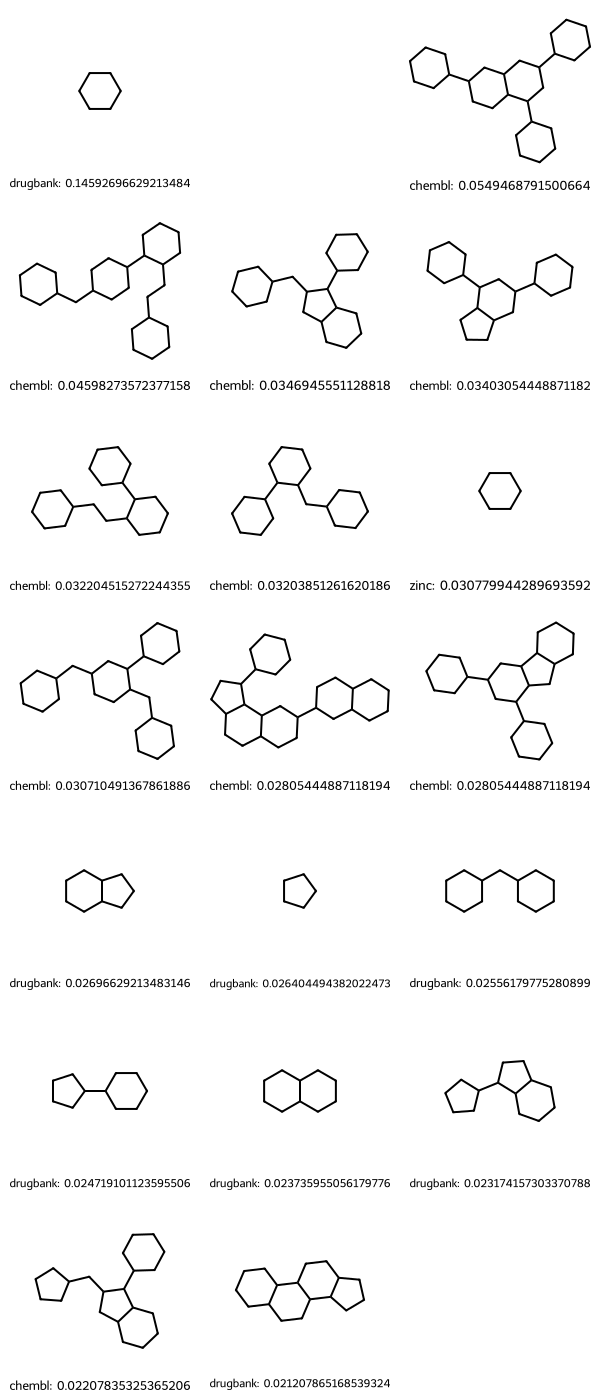

In [54]:
Draw.MolsToGridImage([Chem.MolFromSmiles(m[1]["scaffold_smiles"]) for m in scaffolds[:20].iterrows()], legends=[f'{m[1]["source"]}: {m[1]["prob"]}'for m in scaffolds[:20].iterrows()])

<Axes: xlabel='tsne1', ylabel='tsne2'>

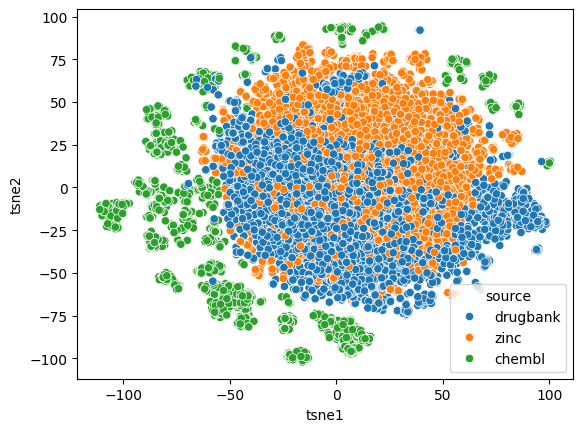

In [56]:
sns.scatterplot(data=structures.sort_values("picked"), x="tsne1", y="tsne2", hue="source")

In [118]:
structures["npa"] = structures["ECFP6"].apply(np.array)

In [123]:
list(structures["npa"])

[array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(1024,)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1

In [ ]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

labels = DBSCAN(eps=7, min_samples=50, metric="jaccard").fit_predict(list(structures["npa"]))
#labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

C:\Users\milan\workspace\cdd2026\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [98]:
labels

array([ 0,  0,  0, ...,  0, 11,  0], shape=(20324,))

In [99]:
structures["cluster"] = [str(l) if l>=0 else "" for l in labels]

In [100]:
structures

,source,mol,ECFP6,explicit_bits,picked,tsne1,tsne2,scaffold,scaffold_smiles,cluster
id,,,,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,11.845649,-62.292377,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCCCCCCCC(CCCCCCCCCCC1CCCC1CCCCCCCCCCC1CC...,0
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",False,13.480247,-63.899030,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCC(CCCCCC(CCC(CCC1CCCC1)CC1CCCC1)CC1CCC2...,0
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",False,13.248928,-60.559788,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C1CCCCC(CC2CCCCC2)CCC(CC2CCCCC2)CCCCCCCC(CC2CC...,0
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",False,11.222519,-64.070340,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCC(CCCCCC(CCC(CCCCC1CCC2CCCCC2C1)CC1CCCC...,0
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,32.557755,-3.473266,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C1CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC1,0
...,...,...,...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",False,5.847549,93.525110,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(CCC2CCCC(C3CCC4CCCCC4C3)C2)CC1,6
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,5.822616,94.154260,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(CCC2CCCC(C3CCC4CCCCC4C3)C2)CC1,6
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,-35.711166,-4.213742,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(C2CCC3CC4CCCC(C5CCCCC5)C4C3C2)CC1,0


<Axes: xlabel='tsne1', ylabel='tsne2'>

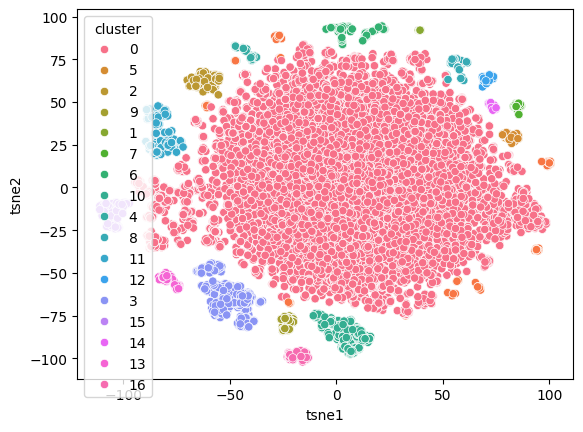

In [101]:
sns.scatterplot(data=structures.sort_values("picked"), x="tsne1", y="tsne2", hue="cluster")

In [107]:
structures

,source,mol,ECFP6,explicit_bits,picked,tsne1,tsne2,scaffold,scaffold_smiles,cluster
id,,,,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,11.845649,-62.292377,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCCCCCCCC(CCCCCCCCCCC1CCCC1CCCCCCCCCCC1CC...,0
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",False,13.480247,-63.899030,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCC(CCCCCC(CCC(CCC1CCCC1)CC1CCCC1)CC1CCC2...,0
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",False,13.248928,-60.559788,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C1CCCCC(CC2CCCCC2)CCC(CC2CCCCC2)CCCCCCCC(CC2CC...,0
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",False,11.222519,-64.070340,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C(CCCCCC(CCCCCC(CCC(CCCCC1CCC2CCCCC2C1)CC1CCCC...,0
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001B68CA...,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,32.557755,-3.473266,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF4...,C1CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC1,0
...,...,...,...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",False,5.847549,93.525110,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(CCC2CCCC(C3CCC4CCCCC4C3)C2)CC1,6
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,5.822616,94.154260,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(CCC2CCCC(C3CCC4CCCCC4C3)C2)CC1,6
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001B68E2...,"[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,-35.711166,-4.213742,<rdkit.Chem.rdchem.Mol object at 0x000001B6AF9...,C1CCC(C2CCC3CC4CCCC(C5CCCCC5)C4C3C2)CC1,0
